# Testing the draft rug plot (`team/new_graphics/rug.py`)

This notebook exercises `make_rug()`, the draft implementation of the new rug plot
type from the approved Task 1E prototype. It is **not** wired into `.plot()` yet —
this is for visually checking the draft before integration.

Sections 1–5 cover the 1D `make_rug()`. **Section 6** covers `make_segmented_rug()`,
the small-n counterpart of the mixed tile plot: for discrete × continuous data it
draws one rug of the continuous values per discrete level, so every point stays
visible.

**How to run:** open this notebook from the `team/new_graphics/new_graphics_demos/`
folder using the `symbulate` conda environment, then Run All.

**What to look for in the 1D rug (Sections 1–5):**
- One thin vertical tick per simulated value, rising from the bottom of the axes
- Stacked/repeated values read as darker ticks (alpha 0.5)
- Rug ticks are consistently short and uniform in height
- When standalone (alone on axes): no y-axis ticks, no spines, no gridlines — clean minimal look
- When overlaying another plot: just the ticks, all axes styling left to the companion plot
- x-axis always reads "Value"

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook lives in <repo>/team/new_graphics/new_graphics_demos/.
REPO_ROOT = Path.cwd().parents[2]

# Make `import symbulate` find the dev copy in this repo (not an older
# installed copy in site-packages), and `from rug import ...` find the
# draft module one folder up.
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(Path.cwd().parent))

# The draft helpers and their per-plot-type constants
from rug import make_rug, make_segmented_rug, RUG_ALPHA, RUG_TICK_HEIGHT

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# Not yet wired into the package, so we apply it by hand here.
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(f"RUG_ALPHA = {RUG_ALPHA}, RUG_TICK_HEIGHT = {RUG_TICK_HEIGHT}")

## 1. Reproduce the approved prototype

This should match the prototype image: ~60 draws from Normal(0, 1), light
sky-blue ticks along the bottom. The short, wide figure matches the prototype
image and is demo-only — the final `.plot()` integration keeps the global
default figure size.

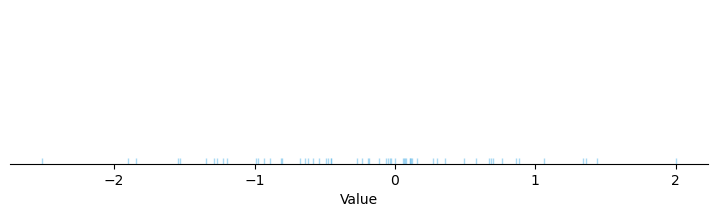

In [26]:
values = rng.normal(0, 1, 60)

plt.figure(figsize=(9, 2))  # demo-only, to match the prototype image
ax = plt.gca()
make_rug(values, ax, "#56B4E9")  # Okabe-Ito sky blue, as in the prototype
plt.show()  # title and axis labels are set automatically by make_rug

## 2. Options: default figure size, custom alpha

The same rug at the package's standard figure size (how it will actually
appear from `.plot()`), then with an alpha override.

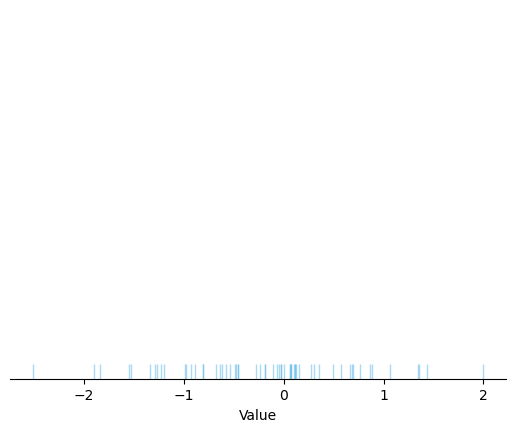

In [27]:
ax = plt.gca()
make_rug(values, ax, "#56B4E9")
plt.show()

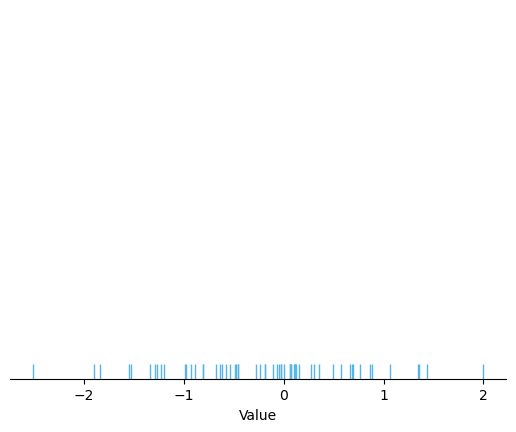

In [28]:
# Fully opaque ticks -- stacked values no longer read as darker
ax = plt.gca()
make_rug(values, ax, "#56B4E9", alpha=1.0)
plt.show()

## 3. Overlay behavior — mimicking two `.plot()` calls

In the final integration, each `.plot()` call takes its color from
`get_next_color(ax)`. Two overlaid rugs should come out in distinct Okabe-Ito
hues, and a legend should appear **automatically in the top right** as soon as
a second rug lands on the axes, auto-named "Variable 1", "Variable 2", ...
A single rug gets no legend.

(Importing `symbulate` currently switches the matplotlib style back to the old
seaborn/ggplot stylesheet — a Phase 2 item — so we re-apply ours right after.)

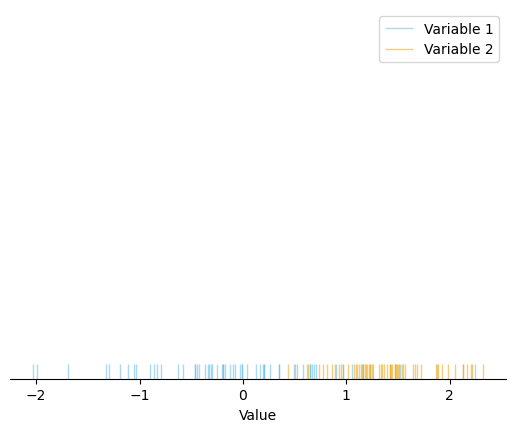

In [29]:
from symbulate.plot import get_next_color

plt.style.use(STYLE_PATH)  # re-apply: importing symbulate overrides the style

sample_a = rng.normal(0, 1, 60)
sample_b = rng.normal(1.5, 0.5, 60)

ax = plt.gca()
make_rug(sample_a, ax, get_next_color(ax))
make_rug(sample_b, ax, get_next_color(ax))  # legend appears on this call
plt.show()

### Custom legend labels

`label=` overrides the automatic "Variable k" names.

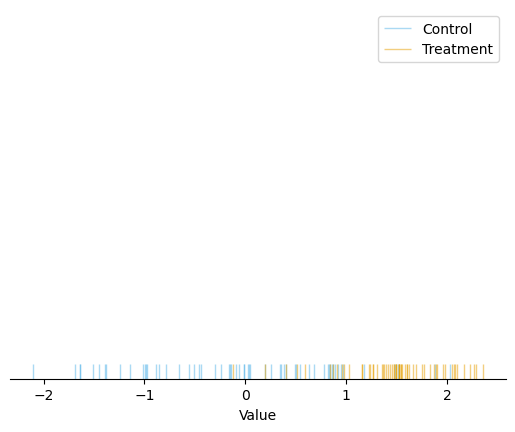

In [30]:
ax = plt.gca()
make_rug(rng.normal(0, 1, 60), ax, "#56B4E9", label="Control")
make_rug(rng.normal(1.5, 0.5, 60), ax, "#E69F00", label="Treatment")
plt.show()

## 4. With real symbulate simulation data

Small-n simulations are exactly where the lookup table will default to a rug
plot, so test with `.sim(50)`.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

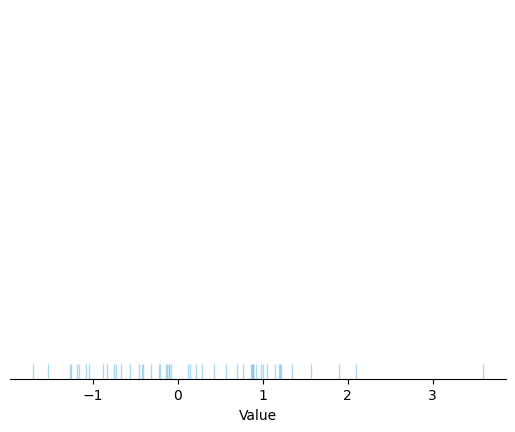

In [31]:
from symbulate import RV, Normal

sims = RV(Normal(0, 1)).sim(50)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_rug(np.asarray(sims.results), ax, "#56B4E9")
plt.show()

## 5. Combined with a density curve — `type=("density", "rug")`

This cell sketches what `.plot(type=("density", "rug"))` will produce: a KDE
density curve of the simulated values, with a short rug of the same values
hugging the x-axis underneath.

When a rug plot is drawn after another plot already exists on the axes, it
automatically detects this and only draws the ticks without modifying any axes
properties. The y-axis, spines, grid, and title are left to the companion plot
type (in this case, the density curve).

The rug ticks are drawn in axes fractions (`RUG_TICK_HEIGHT`, 4% of the axes
height), so they keep their size regardless of the density curve's y-scale.

The density half is drawn with the draft `make_density()` helper from
`team/new_graphics/density.py`.

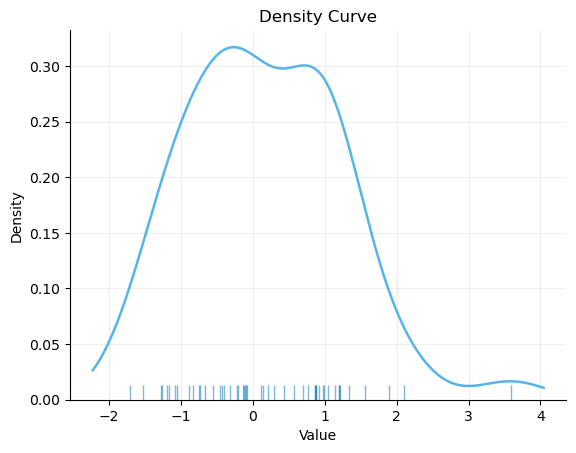

In [32]:
from density import make_density

values = np.asarray(sims.results)

ax = plt.gca()

# The density curve: drawn first, so it owns the y-axis, spines, grid,
# labels, and title. Okabe-Ito sky blue.
make_density(values, ax, "#56B4E9")

# The rug half: automatically detects it's overlaying the density
# curve, so just draws the ticks without modifying any axes properties.
make_rug(values, ax, "#0072B2")

plt.show()

## 6. Segmented rug for mixed data — `make_segmented_rug()`

The small-n counterpart of the mixed tile plot. For discrete × continuous data,
instead of binning the continuous variable it draws one rug of the continuous
values per discrete level, so every individual point stays visible. The bands
stack along whichever axis is discrete, mirroring the tile plot's orientation.

Here `y` is discrete (Poisson levels) and `x` is continuous (Normal, shifted by
the level), so the bands stack **vertically** with **vertical** ticks along x.
The discrete axis is labeled with the levels; the continuous axis keeps numeric
ticks.

In [ ]:
groups = rng.integers(0, 4, 200)            # discrete: 4 levels -> 4 bands
mixed_values = rng.normal(0, 1, 200) + groups  # continuous, shifted by level

ax = plt.gca()
make_segmented_rug(mixed_values, groups, ax, "#56B4E9")  # x continuous, y discrete
plt.show()  # rows = levels, vertical ticks along x

### 6b. Axes swapped — discrete x, continuous y

The same data passed in the other order. Because the segmenting follows the
discrete axis, the bands now stack **horizontally** with **horizontal** ticks
along y — matching how the mixed tile plot flips when `x` is the discrete
variable, so the small-n and large-n views of one dataset stay consistent.

In [ ]:
ax = plt.gca()
make_segmented_rug(groups, mixed_values, ax, "#56B4E9")  # x discrete, y continuous
plt.show()  # columns = levels, horizontal ticks along y

### 6c. Only for mixed data

A segmented rug needs exactly one discrete and one continuous variable. Two
continuous variables (or two discrete) raise a student-friendly error pointing to
the right plot type — scatter for two continuous, tile for two discrete.

In [ ]:
# Two continuous variables -> not a segmented rug; raises a helpful error.
try:
    make_segmented_rug(mixed_values, rng.normal(0, 1, 200), plt.gca(), "#56B4E9")
except ValueError as e:
    print(f"ValueError: {e}")
plt.close("all")  # nothing meaningful was drawn; discard the empty figure

## Verification checklist

- [ ] Section 1 matches the approved prototype image
- [ ] One tick per value; stacked values read as darker ticks
- [ ] Rug ticks are consistently short in height (uniform RUG_TICK_HEIGHT)
- [ ] Standalone rug: no y-axis; no left spine; no gridlines — clean number-line look
- [ ] x-axis always reads "Value"
- [ ] `alpha=` override works
- [ ] Single rug has no legend
- [ ] Legend appears in the top right on the second overlaid rug, auto-named "Variable 1", "Variable 2", ...
- [ ] `label=` overrides the automatic legend names
- [ ] Works on real `.sim()` output, not just numpy arrays
- [ ] Combined with density curve: rug ticks appear at bottom, inherits all axes styling from the density curve (nothing on the axes is modified by the rug)
- [ ] Rug ticks keep their height regardless of the companion plot's y-scale (axes-fraction transform)
- [ ] No `standalone=` parameter needed — detection is automatic
- [ ] Section 6: segmented rug shows one band per discrete level, every point as a tick; discrete axis labeled with the levels, continuous axis numeric
- [ ] Section 6: the ticks are small — the same size as the 1D rug ticks (RUG_TICK_HEIGHT, 4% of the axes) — not large lines spanning each band
- [ ] Section 6b: swapping the arguments flips the orientation — bands stack along whichever axis is discrete (vertical ticks for continuous x, horizontal ticks for continuous y)
- [ ] Section 6c: two continuous (or two discrete) variables raise a student-friendly ValueError pointing to scatter / tile